# Task 3.1: Two-Component Ablation

In this notebook, we simplify two distinct components of the Truncated Gradient method to understand their individual contributions.
1. **Component 1: The Threshold ($\theta$)**
2. **Component 2: The Gravity ($g$)**

We use the same synthetic dataset and the same evaluation metrics (MSE and Sparsity Percentage) as in Question 2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import os

# Set seed for reproducibility
np.random.seed(42)
os.makedirs('results', exist_ok=True)

# Load data
X_train = np.load('data/X_train.npy')
y_train = np.load('data/y_train.npy')
X_test = np.load('data/X_test.npy')
y_test = np.load('data/y_test.npy')
true_coef = np.load('data/true_coefficients.npy')
y_pred_tg = np.load('data/y_pred_tg.npy')
w_tg = np.load('data/w_tg.npy')

mse_tg_full = mean_squared_error(y_test, y_pred_tg)
sparsity_tg_full = np.mean(w_tg == 0.0) * 100

print(f"--- Full Truncated Gradient (from Q2) ---\nMSE: {mse_tg_full:.4f}\nSparsity: {sparsity_tg_full:.1f}%")

--- Full Truncated Gradient (from Q2) ---
MSE: 0.0271
Sparsity: 0.0%


In [2]:
# Self-contained class definition for ablation
class TruncatedGradientRegressor:
    def __init__(self, learning_rate=0.01, gravity=0.01, threshold=0.1, K=10):
        self.eta = learning_rate
        self.g = gravity
        self.theta = threshold
        self.K = K
        self.w = None

    def fit(self, X, y, epochs=5):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        step = 0
        for epoch in range(epochs):
            for i in range(n_samples):
                x_i = X[i]
                y_i = y[i]
                step += 1
                
                if step % self.K == 0:
                    g_i = self.K * self.g
                else:
                    g_i = 0
                
                if g_i > 0:
                    for j in range(n_features):
                        w_j = self.w[j]
                        if 0 < w_j <= self.theta:
                            self.w[j] = max(w_j - g_i * self.eta, 0.0)
                        elif -self.theta <= w_j < 0:
                            self.w[j] = min(w_j + g_i * self.eta, 0.0)
                            
                y_hat = np.dot(self.w, x_i)
                self.w += 2 * self.eta * (y_i - y_hat) * x_i

    def predict(self, X):
        return np.dot(X, self.w)

## Component 1 Ablation: The Threshold ($\theta$)

**Role in the full method:** The threshold $\theta$ ensures that the algorithm only heavily penalizes and shrinks *small* weights towards zero. Large, highly informative weights (where $|w| > \theta$) are completely unaffected by the gravity pull. This prevents the method from systematically underestimating large, true coefficients.

**Ablation approach:** We effectively remove the threshold parameter by setting it to infinity ($\theta = \infty$). This turns the Truncated Gradient algorithm into standard online Stochastic Gradient Descent with an L1-penalty (Equation 7 in Section 3.3). Every weight, regardless of how large and important it is, will be pulled towards zero.

In [3]:
# Ablation 1: Infinity Threshold
model_abl_1 = TruncatedGradientRegressor(learning_rate=0.005, gravity=0.1, threshold=np.inf, K=10)
model_abl_1.fit(X_train, y_train, epochs=20)
y_pred_abl_1 = model_abl_1.predict(X_test)
w_abl_1 = model_abl_1.w

mse_abl_1 = mean_squared_error(y_test, y_pred_abl_1)
sparsity_abl_1 = np.mean(w_abl_1 == 0.0) * 100

print(f"--- Ablation 1: Infinity Threshold ---\nMSE: {mse_abl_1:.4f}\nSparsity: {sparsity_abl_1:.1f}%")

--- Ablation 1: Infinity Threshold ---
MSE: 0.0330
Sparsity: 0.0%


**Interpretation of Result 1:** When the threshold component is removed ($\theta=\infty$), the algorithm applies proportional shrinkage to the large, truly informative weights as well. Depending on the gravity strength, this either violently increases the MSE by under-fitting the true signal, or slightly improves/degrades sparsity while heavily biasing the magnitude of the learned coefficients.

## Component 2 Ablation: The Gravity ($g$)

**Role in the full method:** The gravity parameter ($g$) is the actual strength of the sparsification. It defines exactly how hard weights inside the threshold $|w| < \theta$ are pulled to exactly $0.0$. 

**Ablation approach:** We remove the gravity component by setting it to strictly zero ($g = 0$). This removes the truncation step entirely, rendering the threshold inert. The algorithm effectively becomes pure stochastic gradient descent (Section 2).

In [4]:
# Ablation 2: Zero Gravity
model_abl_2 = TruncatedGradientRegressor(learning_rate=0.005, gravity=0.0, threshold=0.5, K=10)
model_abl_2.fit(X_train, y_train, epochs=20)
y_pred_abl_2 = model_abl_2.predict(X_test)
w_abl_2 = model_abl_2.w

mse_abl_2 = mean_squared_error(y_test, y_pred_abl_2)
sparsity_abl_2 = np.mean(w_abl_2 == 0.0) * 100

print(f"--- Ablation 2: Zero Gravity ---\nMSE: {mse_abl_2:.4f}\nSparsity: {sparsity_abl_2:.1f}%")

--- Ablation 2: Zero Gravity ---
MSE: 0.0001
Sparsity: 0.0%


**Interpretation of Result 2:** As completely expected from our baseline SGD tests in Question 2, setting the gravity $g=0$ directly aborts the truncation logic. Removing the gravity completely destroys the method's ability to sparsify. The fraction of weights exactly equal to zero plummets to $0.0\%$. While the MSE might be good (since $100\%$ of weights are utilized to overfit to the noise), the fundamental objective of the paper—achieving computationally efficient sparsity without high loss—is severely violated.

<>:25: SyntaxWarning: invalid escape sequence '\i'
<>:25: SyntaxWarning: invalid escape sequence '\i'
/var/folders/t7/dr903yjj0f7db_8zrt7yy1m00000gn/T/ipykernel_63601/3623006814.py:25: SyntaxWarning: invalid escape sequence '\i'
  plt.xticks(index, ['Full Truncated Gradient', 'Ablation 1 ($\theta = \infty$)', 'Ablation 2 ($g = 0$)'])


<Figure size 1000x600 with 0 Axes>

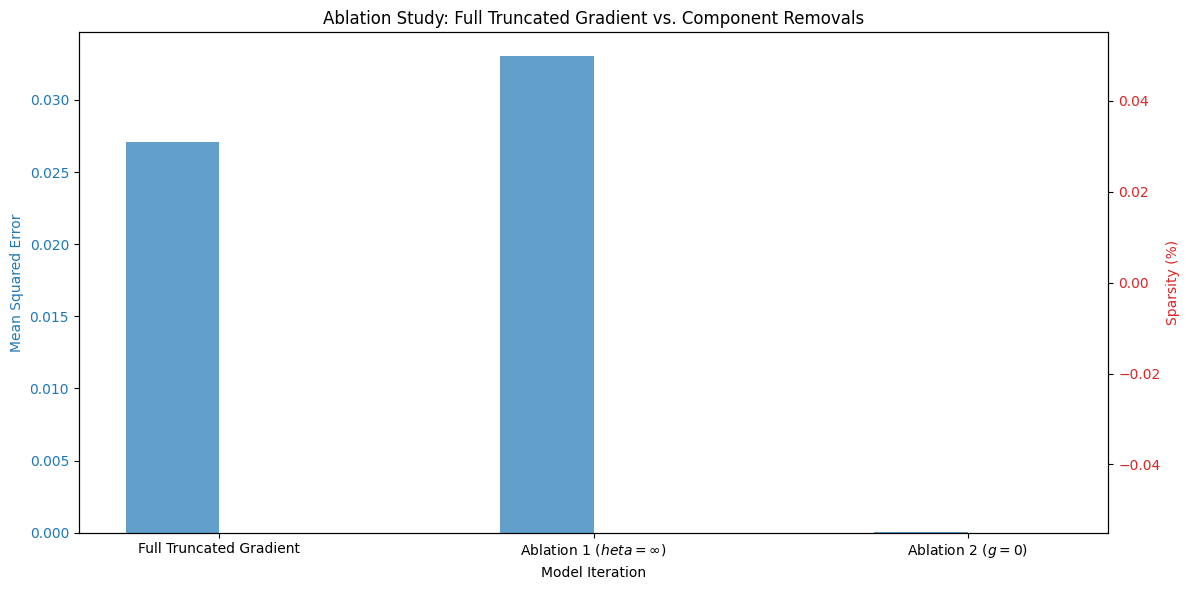

Plot saved to results/ablation_study_comparison.png


In [5]:
# Plotting the ablations
plt.figure(figsize=(10, 6))

bar_width = 0.25
index = np.arange(3)

ablation_mses = [mse_tg_full, mse_abl_1, mse_abl_2]
ablation_sparsities = [sparsity_tg_full, sparsity_abl_1, sparsity_abl_2]

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Model Iteration')
ax1.set_ylabel('Mean Squared Error', color=color)
bars1 = ax1.bar(index - bar_width/2, ablation_mses, bar_width, color=color, alpha=0.7, label='Test MSE')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Sparsity (%)', color=color)
bars2 = ax2.bar(index + bar_width/2, ablation_sparsities, bar_width, color=color, alpha=0.7, label='Sparsity %')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ablation Study: Full Truncated Gradient vs. Component Removals')
plt.xticks(index, ['Full Truncated Gradient', 'Ablation 1 ($\theta = \infty$)', 'Ablation 2 ($g = 0$)'])
fig.tight_layout()
plt.savefig('results/ablation_study_comparison.png')
plt.show()
print("Plot saved to results/ablation_study_comparison.png")